<a href="https://colab.research.google.com/github/SRXKaiser/analitica-de-datos/blob/main/UNIDAD2RegresionLog_23111441.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


**Curso: modelos de aprendizaje**

**UNIDAD 2**


---

*   NOMBRE: Karely Perez Vargas
*   NO CONTROL: 23111441



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
DIR = "/content/drive/MyDrive/Analítica de datos/"
os.chdir(DIR)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Librerías para preprocesamiento e ing de características
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder,StandardScaler, OrdinalEncoder,FunctionTransformer

# Librerías para la canalización
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import make_pipeline

# Librerías para la regresión
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, mean_squared_error, r2_score, confusion_matrix, precision_score,recall_score,accuracy_score
from sklearn.decomposition import PCA

from sklearn.preprocessing import PolynomialFeatures

---

## **<font color=" #895cf9">Explica brevemente el uso de las librerias del segmento de codigo anterior, haciendo uso de la siguiente tabla</font>**


| Library | Explanation  |
|----------|--------------|
|**pandas as pd**| Sirve para la manipulación de datos en estructuras de tipo dataframe para leer, filtrar, agrupar y limpiar	|
|**numpy as np**|Sirve para el calculo numerico, relizar operaciones vectorizadas, arrays y funciones matemáticas	|
|**matplotlib.pyplot as plt**| Sirve para la visualización, creacion de gráficos base, control de figuras y ejes |
|**seaborn as sns** | Sirve para la visualización estadística de graficos de alto nivel |
|**SimpleImputer** |  Sirve para el preoprocesamiento, rellenando valores nulos usando la media, medianay moda|
|**MinMaxScaler** | Sirve para el preprocesamieto de escalas variables al rango
|**OneHotEncoder**|Sirve para el preprocesamieto, conviertiendo variables categóricas en columnas binarias|
|**StandardScaler**|Sirve para el preprocesamieto, estandarizando variables numéricas|
|**OrdinalEncoder**|Sirve para el preprocesamieto codificando categorías con orden|
|**FunctionTransformer**|Sirve para el preprocesamieto aplicando funciones propias|
|**ColumnTransformer** |Sirve para canalización, aplicando transformaciones distintas a distintas columnas|
|**make_column_selector**|Selecciona columnas automaticamente por tipo|
|**make_pipeline** | Encadena pasos de preprocesamiento|
|**LinearRegression**| Modelo de regresión lineal para predecir variables numéricas continuas |
|**LogisticRegression** | Modelo de regresión logística para clasificación|
|**mean_squared_error**| metrica de error cuadratico medio|
|**r2_score**|métrica de coeficiente de determinación|
|**confusion_matrix**|Matriz de confusión|
|**precision_score**|Métrica de precisión|
|**recall_score**|Métrica de sensibilidad|
|**accuracy_score**|Es una métrica de exactitud|
|**PCA**|Reduce el número de variables conservando la mayor varianza.|
|**PolynomialFeatures**|Genera términos polinómicos e interacciones entre variables.|









---

In [ ]:
#lectura del .csv con pandas
data_df = pd.read_csv('/content/drive/MyDrive/Analítica de datos/data.csv')
data_df

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


# **Parte 1**. EDA

Haz que el `id` sea el índice del dataframe y efectúa una exploración inicial de los datos a través de:

In [ ]:
#utilice funcion .set_index()
#Guarde los cambios con inplace=True

#-----------------------------------------------------

data_df.set_index('id',inplace=True)

#-----------------------------------------------------



In [ ]:
data_df

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
id,,,,,,,,,,,,,,,,,,,,,
842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820




1a) Estadísticas descriptivas para todas las variables del dataframe.

In [ ]:
#.describe para variables Numericas
#-----------------------------------------------------
data_df.describe()
#-----------------------------------------------------

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [ ]:
#.describe() para variable categoricas
#-----------------------------------------------------
data_df.describe(include=object)
#-----------------------------------------------------

,diagnosis
count,569
unique,2
top,B
freq,357


1b) Valores únicos por variable para identificar posibles variables categóricas.

In [ ]:
# Recuento de cada categoría única en las variables categóricas
data_df.nunique()


,0
diagnosis,2
radius_mean,456
texture_mean,479
perimeter_mean,522
area_mean,539
smoothness_mean,474
compactness_mean,537
concavity_mean,537
concave points_mean,542
symmetry_mean,432


In [ ]:
# Se hace una lista de variables numéricas y otra de categóricas.

#-----------------------------------------------------
num_cols = data_df.select_dtypes(include=np.number).columns.tolist() #para variables numericas
cat_cols = data_df.select_dtypes(exclude=np.number).columns.tolist() #para variables Categoricas
#-----------------------------------------------------

# Recuento de cada categoría única en las variables categóricas
for column in cat_cols:
  print(column)
  print(data_df[column].value_counts())
  print('-' * 50)

diagnosis
diagnosis
B    357
M    212
Name: count, dtype: int64
--------------------------------------------------


1c) Búsqueda de valores faltantes.

In [ ]:
#Explica cada linea de codigo
print('Número valores faltantes: ') #impresion del titulo de esta seccion de codigo
for col in data_df.columns: #un bucle for que se itera por cada columna que hay en el data frame, se repetira la siguienta accion:
  valor=sum(data_df[col].isna()) #en una variable llamada valor se guardara la sumatoria de la cantidad de datos vacios en cada columna
  porcentaje=data_df[col].isna().mean()*100 #.mean() promedia valores para cubrir los que faltan, y ese valor se transforma en porcentaje al multiplicarlo por 100
  print('{}:{}: porcentaje :{}'.format(col,valor,porcentaje)) #se imprime en pantala la columna, la cantidad de valores vacios, y su porcentaje correspondiente

Número valores faltantes: 
diagnosis:0: porcentaje :0.0
radius_mean:0: porcentaje :0.0
texture_mean:0: porcentaje :0.0
perimeter_mean:0: porcentaje :0.0
area_mean:0: porcentaje :0.0
smoothness_mean:0: porcentaje :0.0
compactness_mean:0: porcentaje :0.0
concavity_mean:0: porcentaje :0.0
concave points_mean:0: porcentaje :0.0
symmetry_mean:0: porcentaje :0.0
fractal_dimension_mean:0: porcentaje :0.0
radius_se:0: porcentaje :0.0
texture_se:0: porcentaje :0.0
perimeter_se:0: porcentaje :0.0
area_se:0: porcentaje :0.0
smoothness_se:0: porcentaje :0.0
compactness_se:0: porcentaje :0.0
concavity_se:0: porcentaje :0.0
concave points_se:0: porcentaje :0.0
symmetry_se:0: porcentaje :0.0
fractal_dimension_se:0: porcentaje :0.0
radius_worst:0: porcentaje :0.0
texture_worst:0: porcentaje :0.0
perimeter_worst:0: porcentaje :0.0
area_worst:0: porcentaje :0.0
smoothness_worst:0: porcentaje :0.0
compactness_worst:0: porcentaje :0.0
concavity_worst:0: porcentaje :0.0
concave points_worst:0: porcentaje :

1d) Diagrama de barras para determinar la frecuencia de los diagnósticos (cantidad de observaciones con resultado benigno y maligno)

<Axes: xlabel='diagnosis', ylabel='count'>

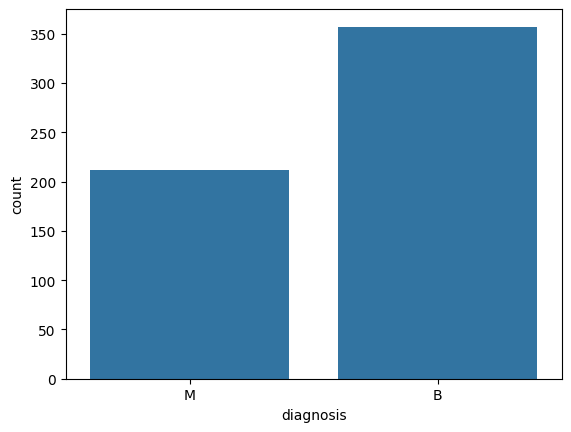

In [ ]:
#utilice sns.countplot()
#-----------------------------------------------------
sns.countplot(x='diagnosis', data=data_df)
#-----------------------------------------------------

2. Como hay tres valores relacionados con la misma característica (`mean`, `se` y `worst`) es muy probable que exista multicolinealidad en el conjunto.

La multicolinealidad en regresión es una condición que ocurre cuando algunas variables predictoras están fuertemente correlacionadas entre sí, de tal manera que si se incluyen simultáneamente en un modelo, impiden explicar de manera correcta el efecto que cada una tiene sobre la variable respuesta. Existen muchas formas de analizar si hay colinealidad en los modelos, una de ellas es el alto coeficiente de correlación entre variables.

Para observar este efecto, elabora un mapa de calor que cuantifique la correlación de las variables numéricas en el dataframe.

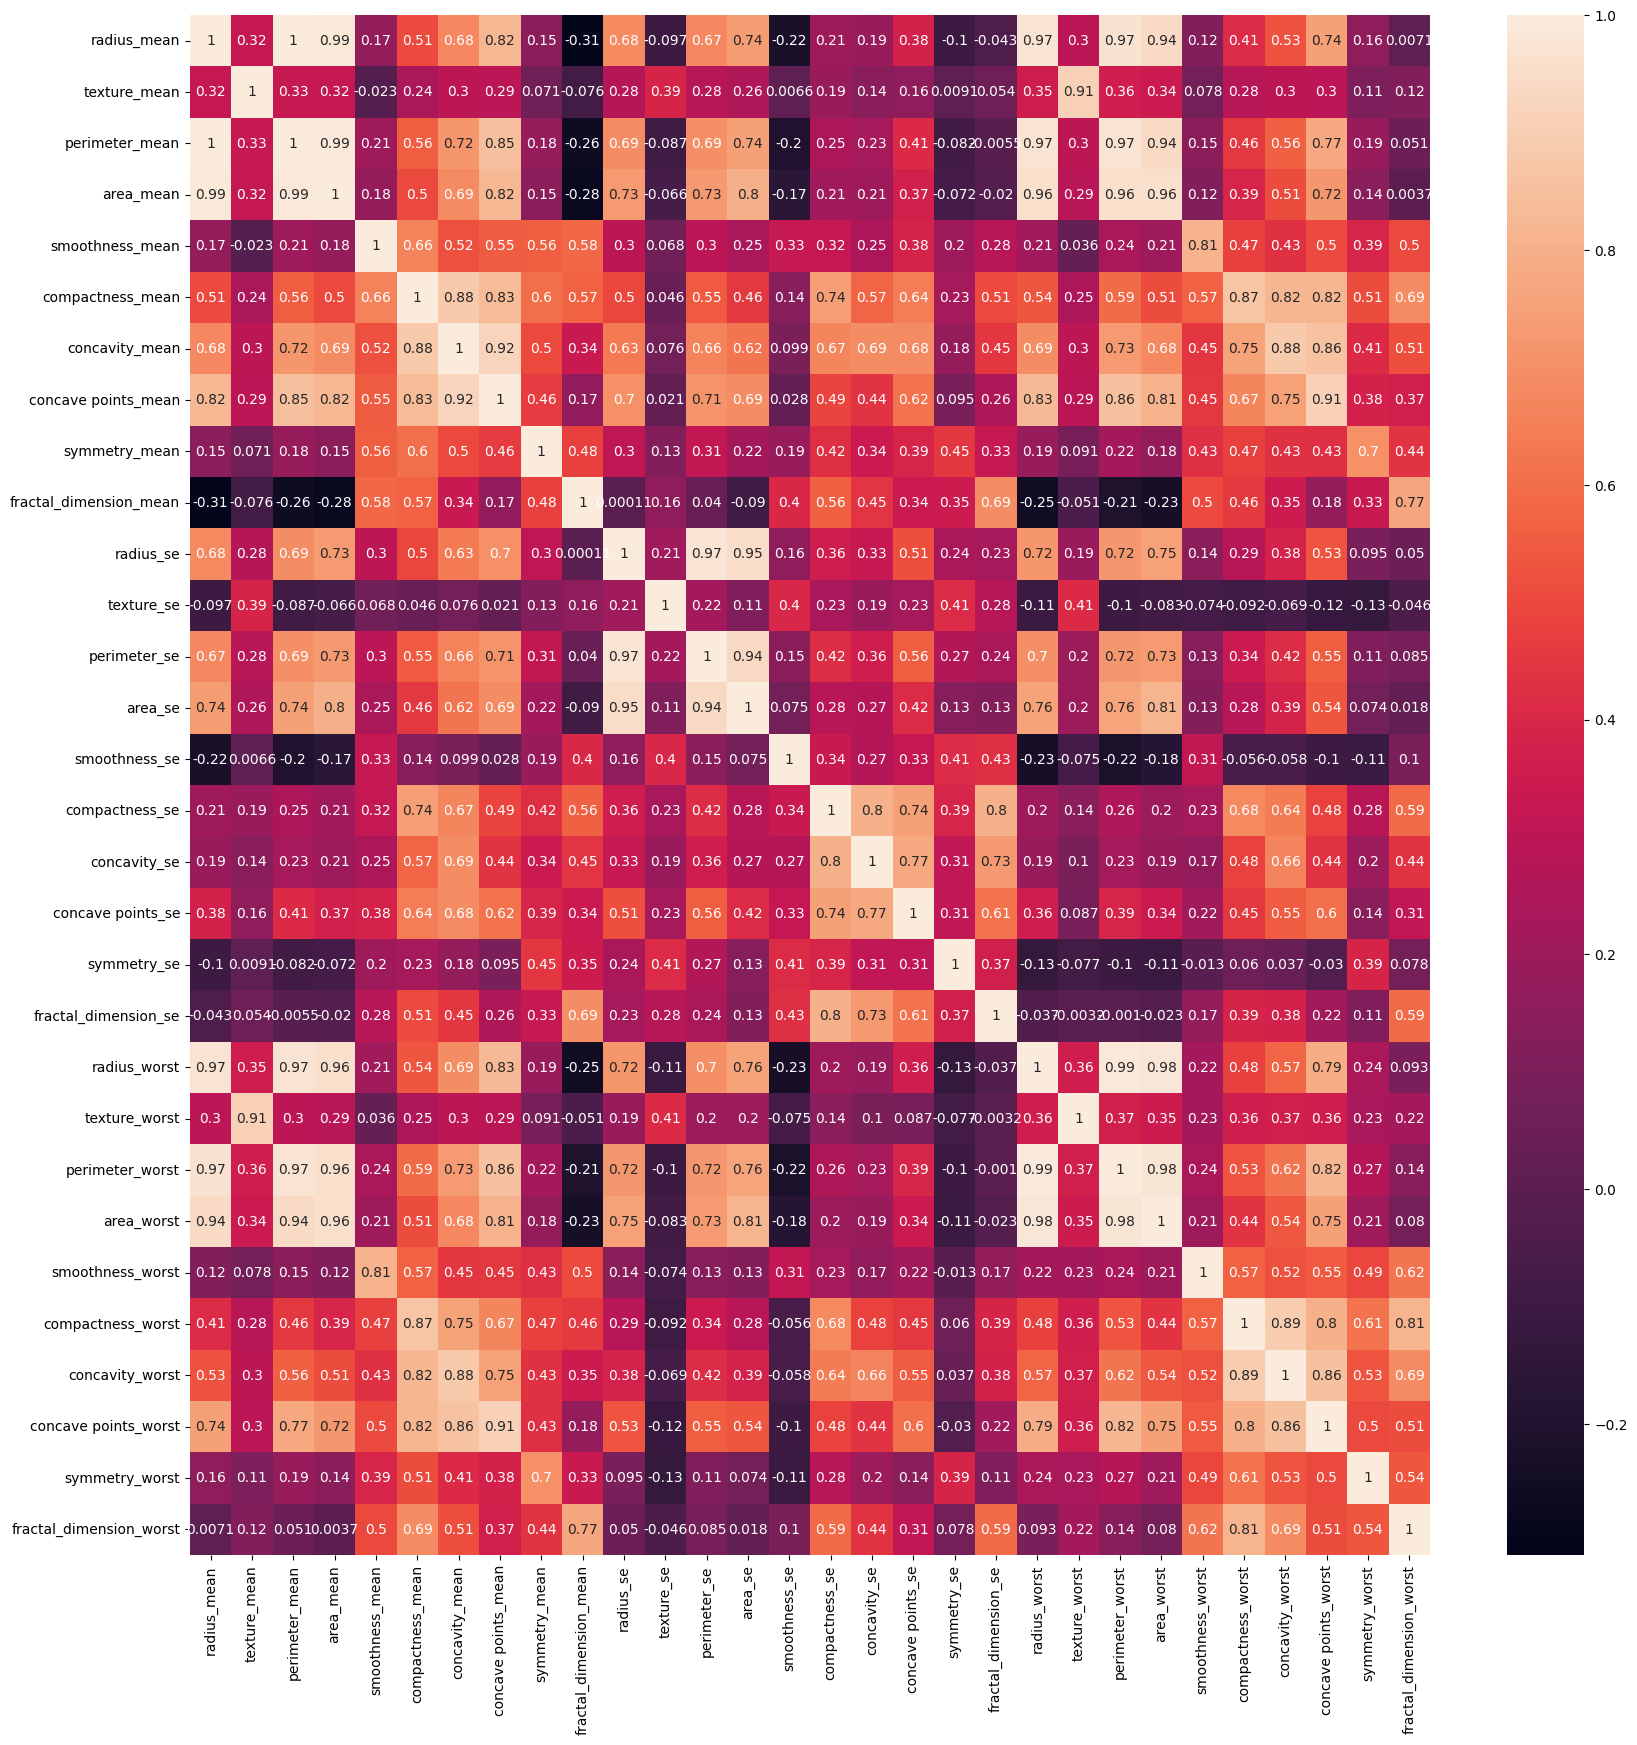

In [ ]:
numeric_df = data_df.select_dtypes(include=[float, int])

#-----------------------------------------------------
plt.figure(figsize=(20, 20))
sns.heatmap(numeric_df.corr(), annot=True)
plt.show()
#-----------------------------------------------------

Si te fijas en los valores de correlación entre las variables `_mean` y `_worst` es evidente la multicolinearidad.

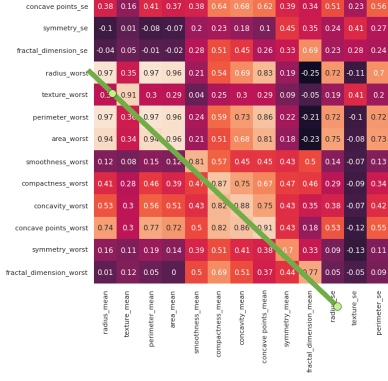

Por ejemplo, la columna `radius_mean` tiene una correlación de 0.97 con la columna `radius_worst`. Esto es algo inevitable, porque las columnas "peores" son esencialmente solo un subconjunto de las columnas "medias".

Para solucionar el problema numérico de la multicolinealidad, tradicionalmente se recurre a eliminar variables o efectuar análisis de componentes principales (PCA) con las `X`’s y usar los componentes como variables independientes en un modelo final.

Conduciremos esta actividad en esos dos sentidos.


# **Parte 2**. Modelo con eliminación de variables altamente correlacionadas  

Elimina las variables altamente correlacionadas:

3a) Ahora que sabes que las variables `_mean` y `_worst` tienen correlación alta, hay que quitar del dataframe un conjunto. Borra las columnas `_worst`.

In [ ]:
#-----------------------------------------------------
#Elimine TODAS las columnas _worst
columnas_a_eliminar=[col for col in data_df.columns if '_worst' in col]
#-----------------------------------------------------

#para borrar las columnas _worst
nuevo_df=data_df.drop(columns=columnas_a_eliminar)

#-----------------------------------------------------
#Convierte new_data_df en Dataframe usando .DataFrame() de la libreria de pandas
nuevo_df = pd.DataFrame(nuevo_df)
nuevo_df
#-----------------------------------------------------

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se
id,,,,,,,,,,,,,,,,,,,,,
842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193
842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532
84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571
84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208
84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,1.1760,1.2560,7.673,158.70,0.010300,0.02891,0.05198,0.02454,0.01114,0.004239
926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,0.7655,2.4630,5.203,99.04,0.005769,0.02423,0.03950,0.01678,0.01898,0.002498
926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,0.4564,1.0750,3.425,48.55,0.005903,0.03731,0.04730,0.01557,0.01318,0.003892


En las graficas de dispersion, los patrones lineales en los diagramas de dispersion se refieren a la relacion entre dos variables que sigue una tendencia aproximadamente en linea recta, ya sea en direccion ascendente o descentende

* **Patron lineal positivo**: Si la linea se inclina hacia arriba (de izquierda a derecha), indica que hay una relacion directa entre las variables: cuando la variable aumenta, la otra tambien lo hace, es decir, CORRELACION POSITIVA

* **Patron lineal negativo**: si la linea se incluna hacia abajo (de izquierda a derecha), indica quue cuando una variable aumenta, la otra disminuye, es decir, CORRELACION NEGATIVA

* **Patron lineal perfecto**, si los puntos siguen una linea recta perfecta, la relacion entre las variables es exactamente lineal, sin desviaciones.


3b. Entre las variables `_mean`, identifica patrones lineales con diagramas de dispersión usando:

    sns.pairplot(data=nuevo_df[['radius_mean',
        'texture_mean',
        'perimeter_mean',
        'area_mean',
        'smoothness_mean',
        'compactness_mean',
        'concavity_mean',
        'concave points_mean',
        'symmetry_mean',
        'fractal_dimension_mean']])



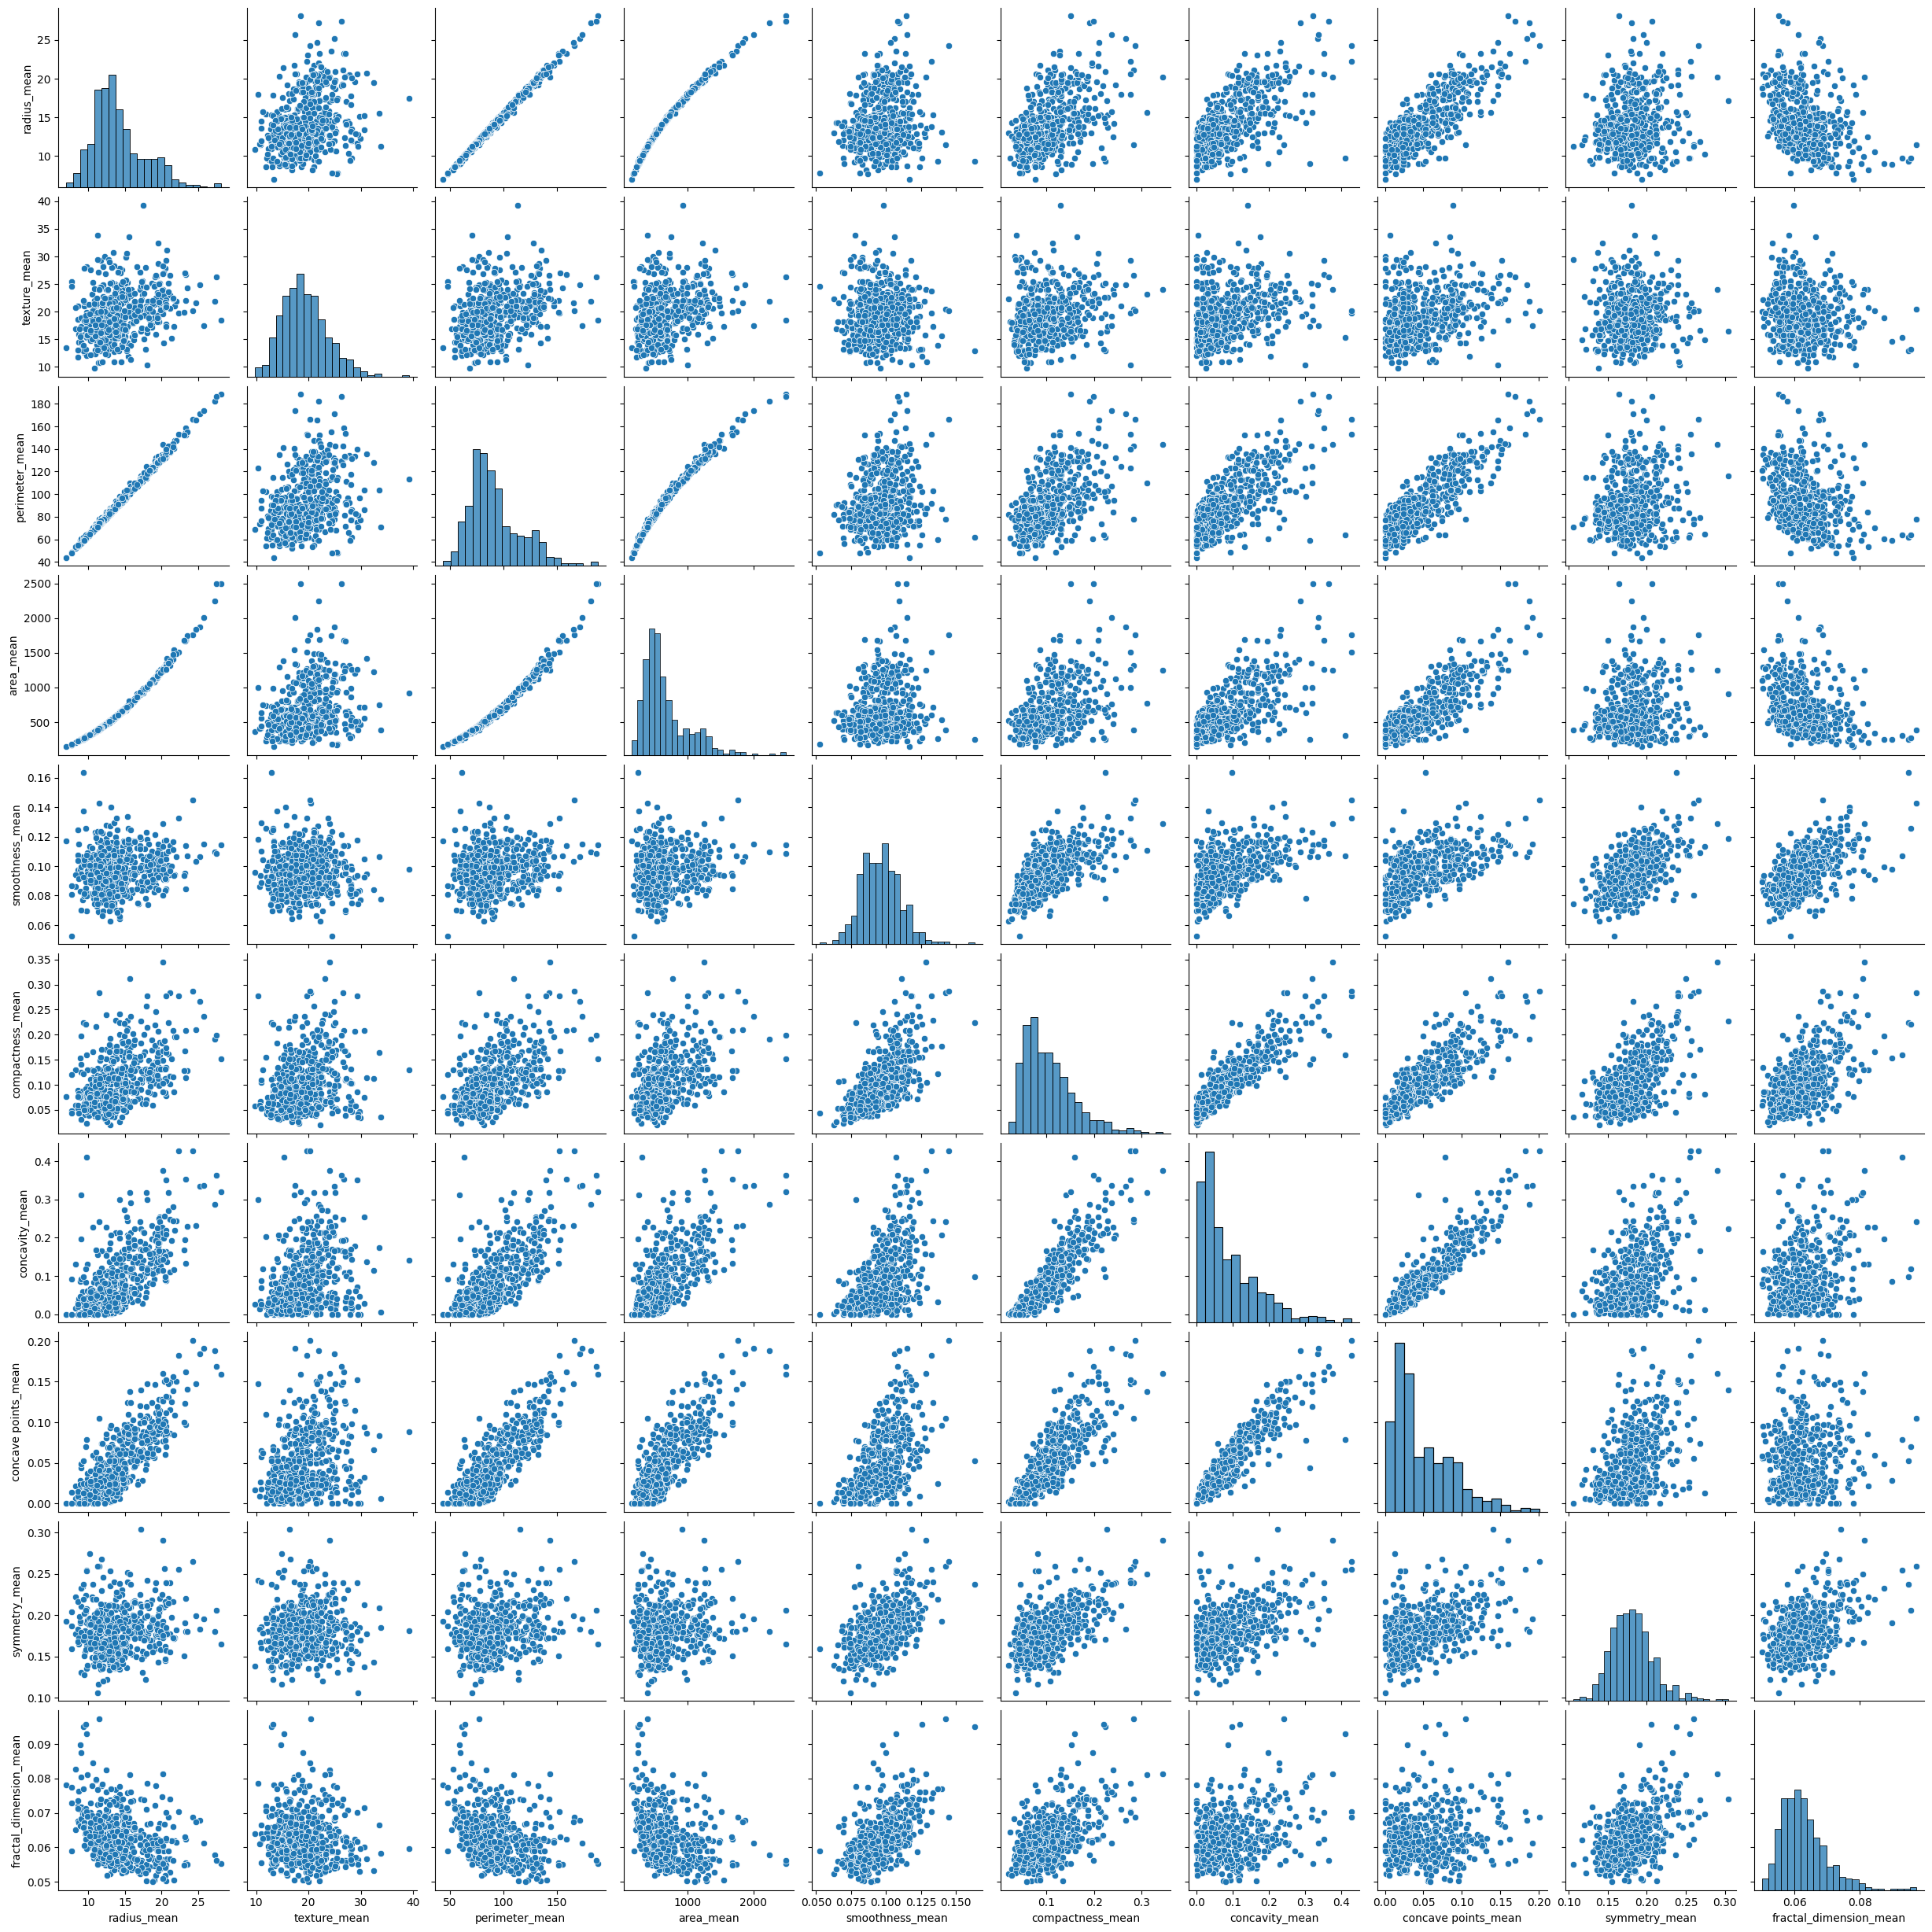

In [ ]:
#-----------------------------------------------------
#Pega aqui el codigo sns.pairplot()
sns.pairplot(data=nuevo_df[['radius_mean',
    'texture_mean',
    'perimeter_mean',
    'area_mean',
    'smoothness_mean',
    'compactness_mean',
    'concavity_mean',
    'concave points_mean',
    'symmetry_mean',
    'fractal_dimension_mean']])

plt.show()
#-----------------------------------------------------

De la matriz podrás observar relaciones lineales bastante evidentes entre:


*   `radius_mean`, `perimeter_mean` y `area_mean`
*   `compactness_mean`, `concavity_mean`, `concave_points_mean`

Sabemos que el perímetro y el área de un círculo, se calculan a partir del radio. Entonces, la relación entre las primeras tres variables es muy clara para nosotros.

3c) Elabora otro mapa de calor confirmar con los valores de correlación.


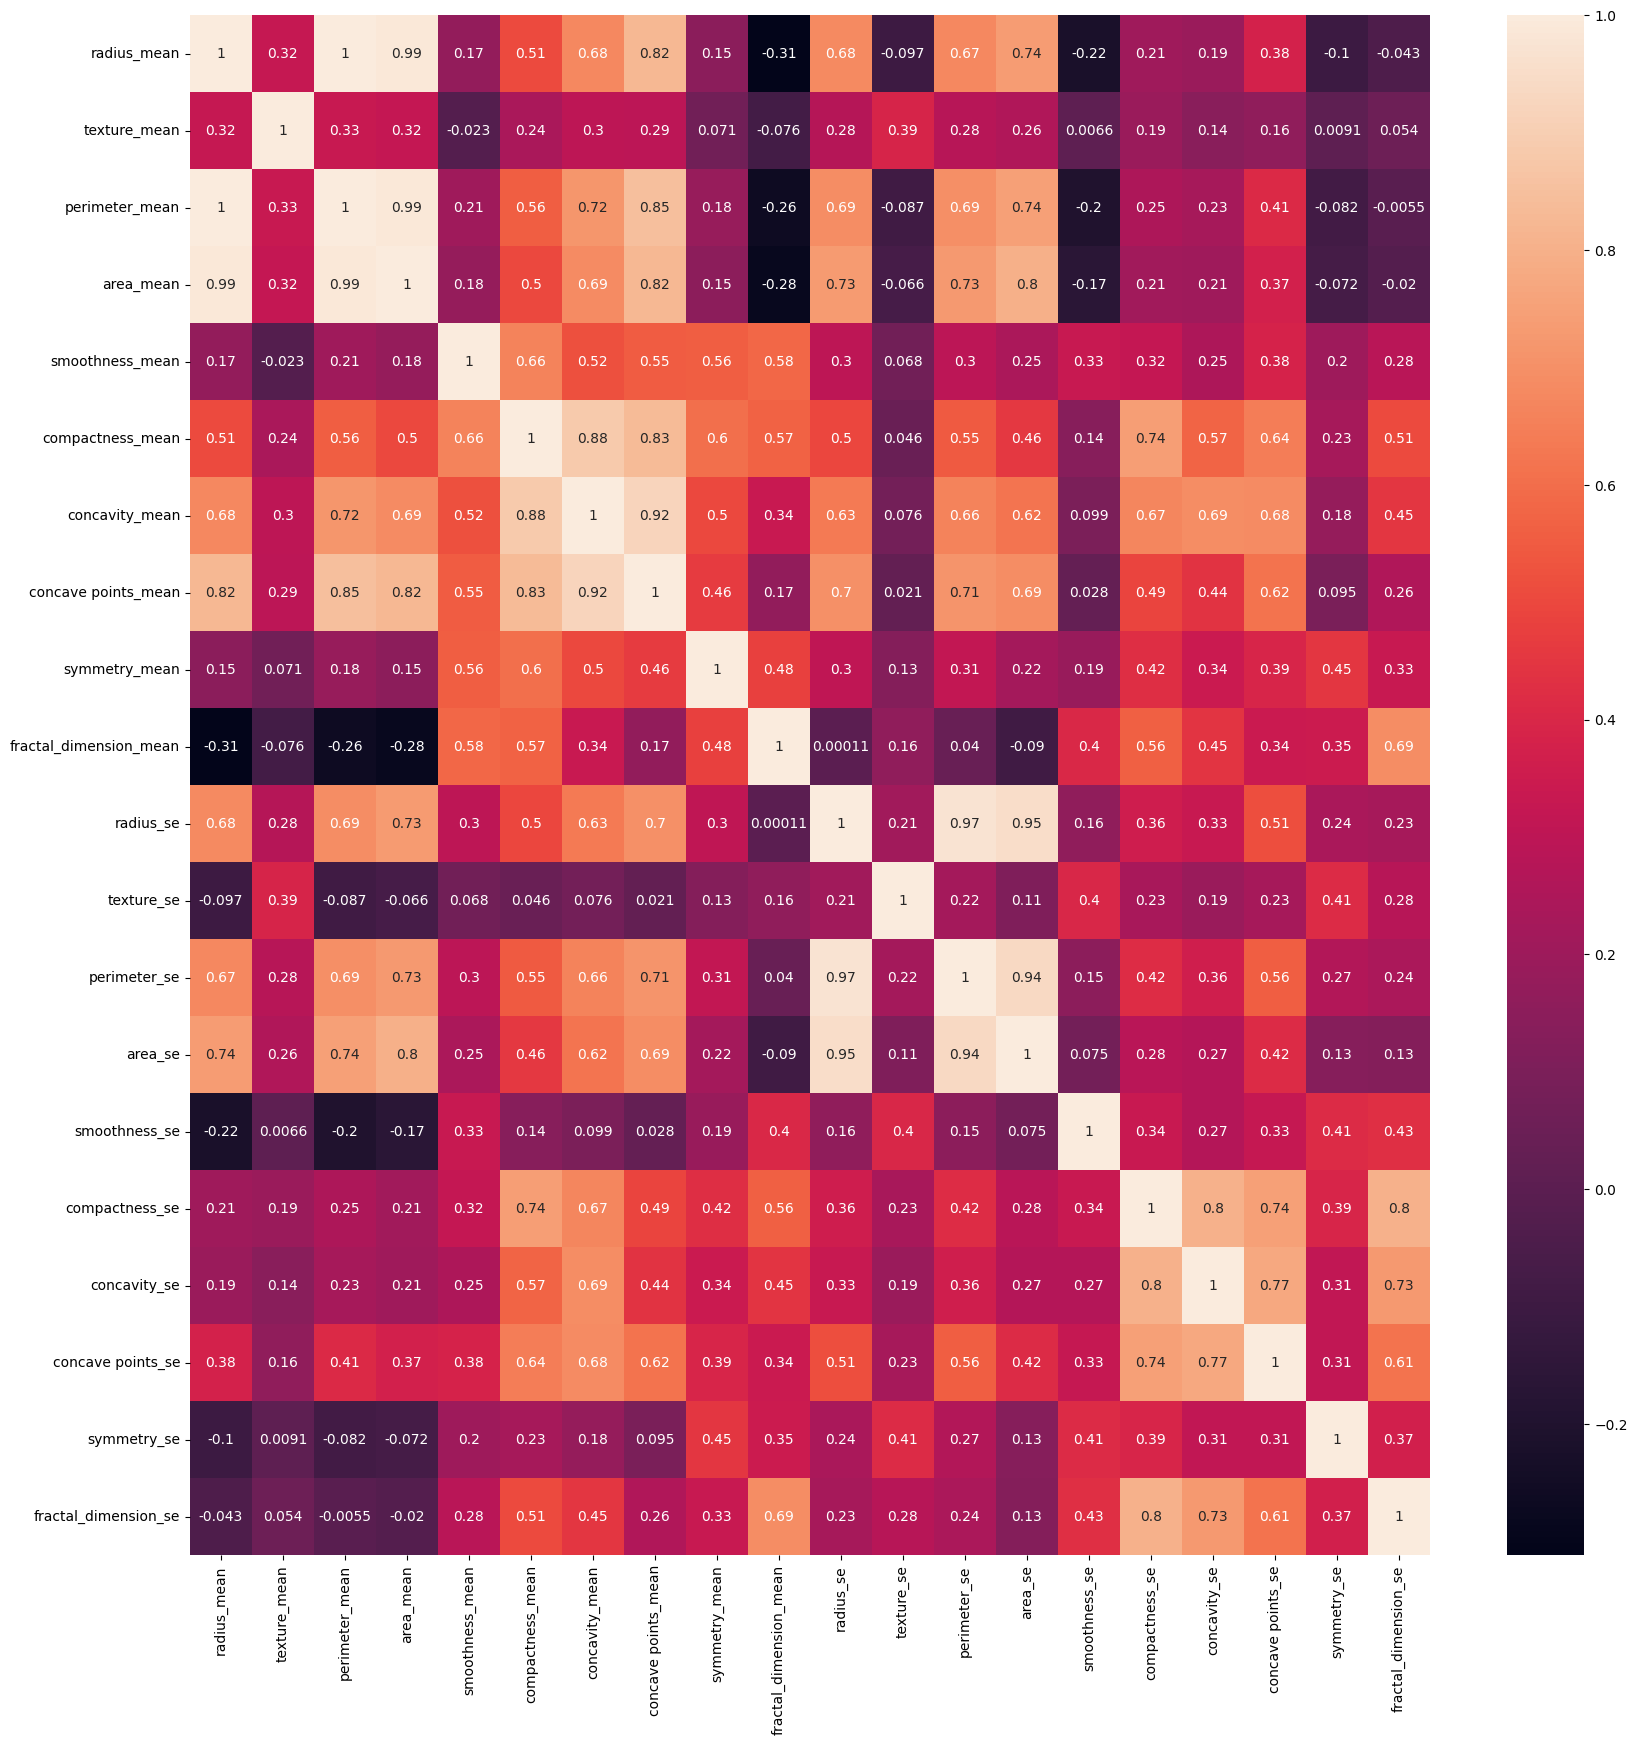

In [ ]:
#-----------------------------------------------------
#Agrega codigo para el mapa de calor
numeric_df_nuevo = nuevo_df.select_dtypes(include=[float, int])

#-----------------------------------------------------
plt.figure(figsize=(20, 20))
sns.heatmap(numeric_df_nuevo.corr(), annot=True)
plt.show()
#-----------------------------------------------------

3d) Después de observar los valores, nos quedaremos con sólo una variable de cada trío: `radius_mean` y `compactness_mean`. Elimina las restantes, no sólo del conjunto `_mean`, sino también de `_se`.

In [ ]:

#-----------------------------------------------------
#escriba TODAS las columnas que seran eliminadas
columnas_a_eliminar=[
    'perimeter_mean',
    'area_mean',
    'concavity_mean',
    'concave points_mean',
    'perimeter_se',
    'area_se',
    'concavity_se',
    'concave points_se'
]
#-----------------------------------------------------

#-----------------------------------------------------
#Convierte new_data_df en Dataframe usando .DataFrame() de la libreria de pandas
new_data_df=pd.DataFrame(nuevo_df.drop(columns=columnas_a_eliminar))
new_data_df
#-----------------------------------------------------


,diagnosis,radius_mean,texture_mean,smoothness_mean,compactness_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,smoothness_se,compactness_se,symmetry_se,fractal_dimension_se
id,,,,,,,,,,,,,
842302,M,17.99,10.38,0.11840,0.27760,0.2419,0.07871,1.0950,0.9053,0.006399,0.04904,0.03003,0.006193
842517,M,20.57,17.77,0.08474,0.07864,0.1812,0.05667,0.5435,0.7339,0.005225,0.01308,0.01389,0.003532
84300903,M,19.69,21.25,0.10960,0.15990,0.2069,0.05999,0.7456,0.7869,0.006150,0.04006,0.02250,0.004571
84348301,M,11.42,20.38,0.14250,0.28390,0.2597,0.09744,0.4956,1.1560,0.009110,0.07458,0.05963,0.009208
84358402,M,20.29,14.34,0.10030,0.13280,0.1809,0.05883,0.7572,0.7813,0.011490,0.02461,0.01756,0.005115
...,...,...,...,...,...,...,...,...,...,...,...,...,...
926424,M,21.56,22.39,0.11100,0.11590,0.1726,0.05623,1.1760,1.2560,0.010300,0.02891,0.01114,0.004239
926682,M,20.13,28.25,0.09780,0.10340,0.1752,0.05533,0.7655,2.4630,0.005769,0.02423,0.01898,0.002498
926954,M,16.60,28.08,0.08455,0.10230,0.1590,0.05648,0.4564,1.0750,0.005903,0.03731,0.01318,0.003892


Observa la distribución de las variables resultantes (deben ser 12, sin contar la columna de indice):

4a) Utilizando histogramas. Guarda en una variable (`skew_cols`) las que tengan marcado sesgo positivo. Para dar seguridad a tu selección, elige aquellas cuyo resultado de aplicar la función `skew()` sea mayor a 1.

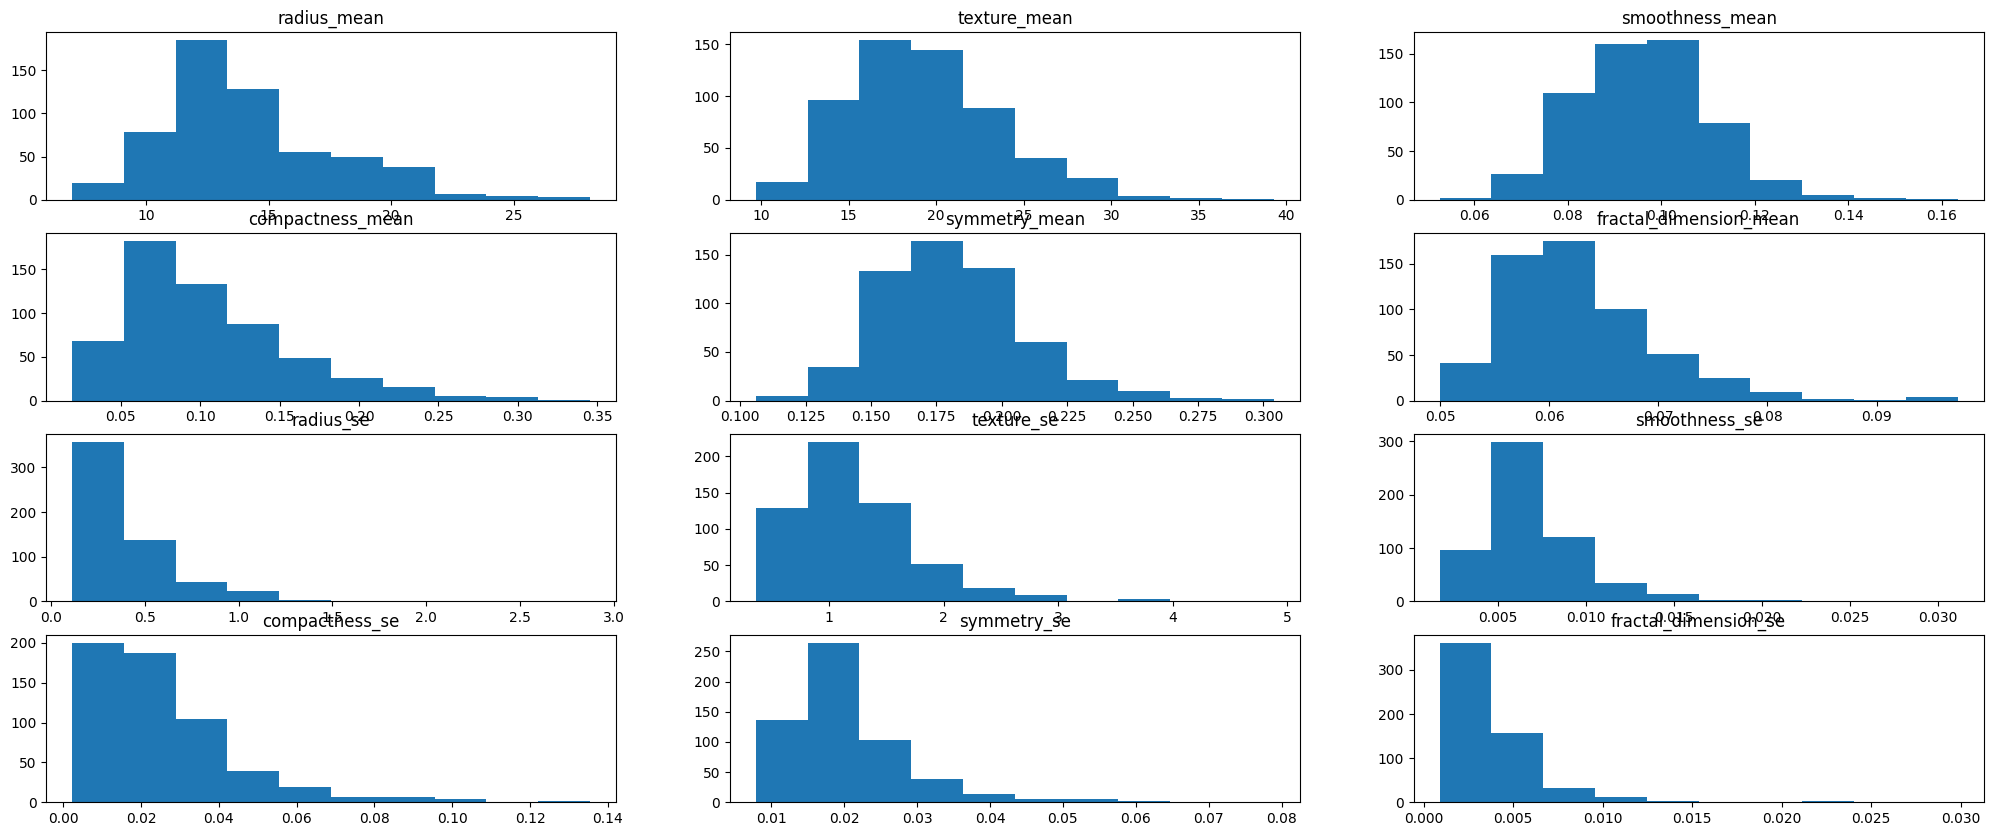

In [ ]:
#EXPLICA CADA LINEA DE CODIGO
skew_cols_df=pd.DataFrame() #creacion de dataframe para almacenar las columnas con valores numericos
fig, axes =plt.subplots(4,3, figsize=(25,10)) #25 es el ancho, 10 altura   ---- 4,3 significa que seran  4 filas y 3 columnas
axes = axes.ravel() #para poder acceder a los indices de la matriz con facilidad, se usa mucha al trabajar con cuadricula
num_cols = new_data_df.select_dtypes(include=np.number).columns.tolist() #seleccion unicamente de las variables numericas y crea una lista de estas columnas


for col, ax in zip (num_cols, axes): #bucle for que se iterara por cada indice ax en num_cols
  ax.hist(new_data_df[col]) #se crea un histograma con las columnas del dataframe ya escogidas
  ax.set(title = f'{col}', xlabel=None) #se establece como titulo de cada barra del histograma, el nombre de su columna correspondiente
  if new_data_df[col].skew()>1 : skew_cols_df[col] =new_data_df[col] #condición que indica el sesgo de las columnas

skew_cols = skew_cols_df.columns.values #guarda el nombre de las columnas para mas adelante aplicarles transformacion R2



In [ ]:
skew_cols

array(['compactness_mean', 'fractal_dimension_mean', 'radius_se',
       'texture_se', 'smoothness_se', 'compactness_se', 'symmetry_se',
       'fractal_dimension_se'], dtype=object)

4b) Dibujando box plots de todas las variables. Guarda en una variable (`scale_cols`) aquellas que no se encuentren en el intervalo [0,1]


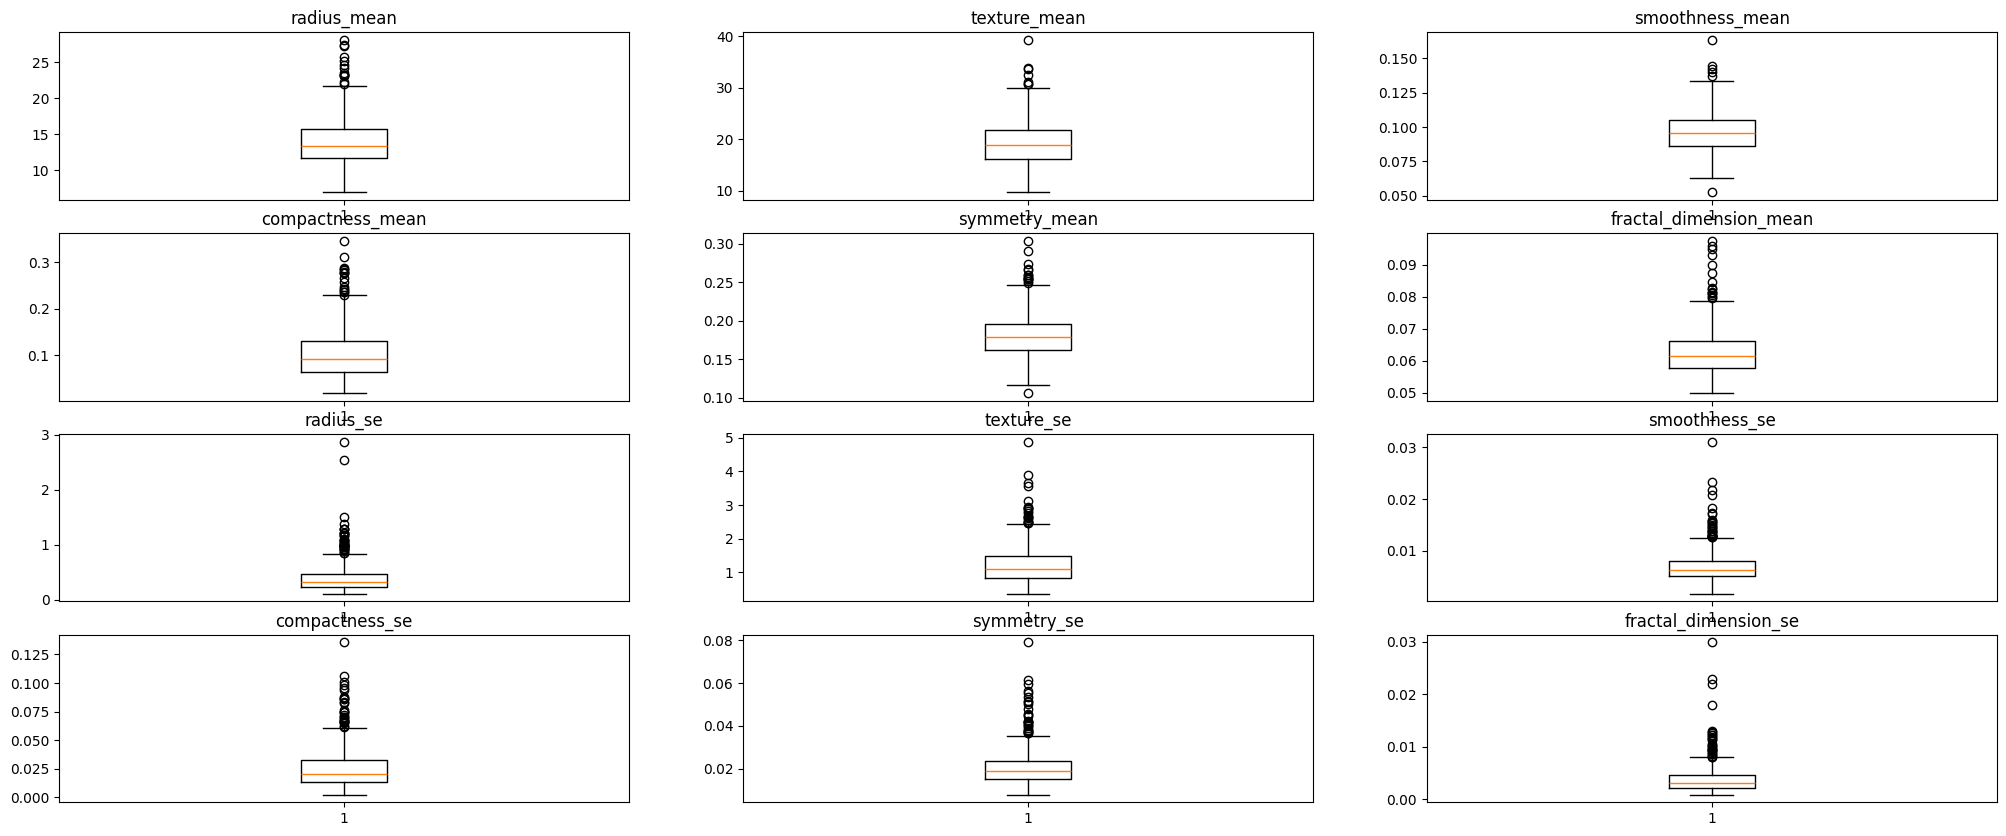

In [ ]:
scale_cols_df=pd.DataFrame()
fig, axes = plt.subplots(4,3, figsize=(25,10))
axes = axes.ravel()
num_cols = new_data_df.select_dtypes(include=np.number).columns.tolist()

#-----------------------------------------------------
for col, ax in zip(new_data_df[num_cols], axes):

  ax.boxplot(new_data_df[col]) #COMPLETA LINEA DE CODIGO

  ax.set(title=f'{col}', xlabel=None)

  #COMPLETA EL IF
  if not (new_data_df[col].min() >= 0 and new_data_df[col].max() <= 1):
    scale_cols_df[col] = new_data_df[col]
#-----------------------------------------------------

scale_cols = scale_cols_df.columns.values



In [ ]:
scale_cols

array(['smoothness_mean', 'compactness_mean', 'symmetry_mean',
       'fractal_dimension_mean', 'smoothness_se', 'compactness_se',
       'symmetry_se', 'fractal_dimension_se'], dtype=object)

Con todo el análisis anterior, estamos listos para generar un modelo *baseline* denominado `logr_model`. Para ello:

5a) Vuelve a leer el contenido del archivo, haz que el `id` sea el índice y separa las variables del dataframe: en `X` coloca los predictores y en `y` la variable de respuesta o salida (`diagnosis`). Divide el conjunto en entrenamiento y prueba (80:20) considerando el parámetro `random_state` con el valor de 1.

In [ ]:
data_df = pd.read_csv('data.csv')

#-----------------------------------------------------
#AGREGA LINEA DE CODIGO PARA CONVERTIR COLUMNA "ID" EN INDICE
data_df.set_index('id', inplace=True)
#-----------------------------------------------------

data_df

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
id,,,,,,,,,,,,,,,,,,,,,
842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820


In [ ]:
X = data_df.copy() #Se crea copia del df


#-----------------------------------------------------
#                                  COMPLETA CODIGO
# se elimina variable Categorica "diagnosis" de (X), debido a se sera utilizada como variable de salida (y)
#-----------------------------------------------------
#Especifique la columna que desea eliminar
#Utilice el parametro axis=1, permitira eliminar la columna
#Guarde los cambios agregando el parametro inplace=True

X.drop('diagnosis', axis=1, inplace=True) #Caracteristica / variable Entrada
#-----------------------------------------------------

#-----------------------------------------------------
y = data_df['diagnosis'] #Objetivo /Variable salida
#-----------------------------------------------------

In [ ]:
#Libreria necesaria para realizar la particion del conjunto de datos
from sklearn.model_selection import train_test_split

# Se divide el conjunto en entrenamiento y prueba (80:20), es decir, 80% para Entrenamiento (train) y 20% para Prueba (test)
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=1)

5b) Prepara un transformador, denominado `preprocessing`, para borrar las columnas altamente correlacionadas (las 18 variables que se determinaron en los ejercicios previos) Asegúrate de incluir el parámetro `remainder='passthrough'` para mantener el resto de las variables.

In [ ]:
#EXPLIQUE CADA LINEA DE CODIGO
columnas_a_eliminar=['radius_worst','texture_worst','perimeter_worst','area_worst','smoothness_worst','compactness_worst','concavity_worst','concave points_worst','symmetry_worst','fractal_dimension_worst','perimeter_mean','area_mean','concavity_mean','concave points_mean','perimeter_se','area_se','concavity_se','concave points_se']

preprocessing = ColumnTransformer([
    ('num', 'drop', columnas_a_eliminar)]
   ,remainder='passthrough')


5c) Entrena el modelo `logr_model` con el transformador `preprocessing` y  regresión logística.

Como la salida `y` está en términos de las etiquetas `'B'` y `'M'`, en lugar de 0 y 1, para evaluar el modelo en el conjunto de prueba deberás especificar la clase positiva. En el caso de la matriz de confusión, indica el orden de las etiquetas con `labels=['B','M']`, porque `'B'` es la clase negativa (ésta se especifica primero) y `'M'` la positiva. Para las métricas de *recall* y *precision*, utiliza el parámetro `pos_label='M'`. Como *accuracy* ocupa la suma de ambas clases y el total de las observaciones, no requiere ninguna especificación. Si quisieras omitir estos parámetros, tendrías que sustituir `'B'` por 0 y `'M'` por 1, previo a la construcción del modelo.

In [ ]:
#EXPLIQUE CADA LINEA DE CODIGO

# se crea un pipeline que primero aplica el preprocesamiento (borrado de columnas) y luego el modelo de regresión logística.
logr_model = make_pipeline(preprocessing, LogisticRegression(max_iter=10000))

# se entrena el pipeline con los datos de entrenamiento.
logr_model.fit(Xtrain, ytrain)

# se realizan las predicciones sobre el conjunto de prueba.
predictions = logr_model.predict(Xtest)

# se imprimen las métricas de evaluación del modelo.
print('matriz de confusion 1:\n', confusion_matrix(ytest, predictions, labels=['B', 'M']))
print('recall    :\t', recall_score(ytest, predictions, pos_label='M'))
print('precision :\t', precision_score(ytest, predictions, pos_label='M'))
print('accurancy :\t', accuracy_score(ytest, predictions))

matriz de confusion 1:
 [[68  4]
 [10 32]]
recall    :	 0.7619047619047619
precision :	 0.8888888888888888
accurancy :	 0.8771929824561403


<font color=" ORANGE">INTERPRETE LOS RESULTADOS OBTENIDOS EN MATRIZ DE CONFUSION Y METRICAS

Para generar un modelo `logr_model2` con transformación y escalamiento:

6a) Modifica el transformador anterior para, además del borrado de las columnas correlacionadas, aplicar la raíz cuadrada a los predictores con sesgo (previamente almacenados en `skew_cols`) y escalamiento *MinMax* a los predictores con escala mayor a 1 (previamente almacenados en `scale_cols`) Como no todos los predictores serán eliminados o transformados, asegúrate de incluir el parámetro `remainder='passthrough'`

In [ ]:
#EXPLIQUE CADA LINEA DE CODIGO
preprocessing2 = ColumnTransformer([ #se crea una variable con la clase column transformer, definiendo una lista de tuplas, este sirve para aplicar transformaciones
    ('num0','drop', columnas_a_eliminar), #se eliminan las columnas redundantes
    ('num1',FunctionTransformer(np.sqrt),skew_cols), #se reduce el sesgo positivo de esas variables
    ('num2',MinMaxScaler(),scale_cols) #para que todas las variables tengan la misma magnitud
  ],remainder='passthrough') #cierre de transformaciones y el passthrough indica que las columnas no mencionadas en las transformaciones se quedaran iguales

6b) Entrena el modelo `logr_model2` con regresión logística, aplicando previamente el transformador modificado. Evalúa el modelo en el conjunto de prueba con las mismas métricas.

In [ ]:
#ESCRIBA CODIGO AQUI
logr_model2 = make_pipeline(preprocessing2, LogisticRegression(max_iter=10000))
logr_model2.fit(Xtrain, ytrain)
predictions2 = logr_model2.predict(Xtest)

print('matriz de confusion 2:\n', confusion_matrix(ytest, predictions2, labels=['B', 'M']))
print('recall    :\t', recall_score(ytest, predictions2, pos_label='M'))
print('precision :\t', precision_score(ytest, predictions2, pos_label='M'))
print('accurancy :\t', accuracy_score(ytest, predictions2))


matriz de confusion 2:
 [[72  0]
 [11 31]]
recall    :	 0.7380952380952381
precision :	 1.0
accurancy :	 0.9035087719298246


<font color=" ORANGE">INTERPRETE LOS RESULTADOS OBTENIDOS EN MATRIZ DE CONFUSION Y METRICAS


TN: 72. Se redujeron los falsos positivos a 0.

FP: 0.

FN: 11. Aumento el número de falsos negativos de 4 a 11.

TP: 31. Se redujo el número de verdaderos positivos de 32 a 31.

Recall (Sensibilidad): 0.73. El recall ahora identifica correctamente el 73% de los tumores malignos.

Precisión: 1.00. La precisión es perfecta. Todas las predicciones de malignidad fueron correctas.

Exactitud (Accuracy): 0.903. La exactitud general del modelo mejoró al 90.3%.

<font color=" ORANGE">CONCLUSION DE LA PRACTICA

En esta practica, se pudieron poner en practica las principles estrategias de eliminacion de variables correlacionadas, eliminando variables correlacionadas para simplificar el modelo y mitigar el efecto negativo de la multicolinealidad.
Y la mejora del procesamiento, aplicando trnaformaciones especifica a las varuables restntes para corregir sesgos de ciertas variables, ayudando a mejorar el rendimiento de algoritmos de aprendizaje.

El resultado final (modelo logr_model2) demostró una mejora notable en comparación con el modelo baseline (logr_model). Las métricas de precisión, y exactitud aumentaron, y la matriz de confusión mostró una drástica reducción de errores, especialmente de los falsos positivos.